In [23]:
#load library
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [24]:
#load and prepare data
# Upload the file to the Colab environment
print("Please upload the 'heart (1).csv' file:")
uploaded = files.upload()

# Assuming only one file is uploaded, get its name
file_name = next(iter(uploaded))

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)
df = pd.read_csv(file_name)

Please upload the 'heart (1).csv' file:


Saving framingham.csv to framingham (1).csv


In [25]:
#Data info
print(df.isnull().sum())
df.info()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   t

In [26]:
col=df.columns
df[col]=df.fillna(df[col].mean(),axis=0)

In [27]:
df.isna().sum()

,0
male,0
age,0
education,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0


In [28]:
# Prepare DL model

# Assuming 'TenYearCHD' is the target variable
y = df['TenYearCHD']

# Identify feature columns to match the model's input_shape=(13,)
# Dropping 'TenYearCHD', 'education', and 'BPMeds' to get 13 features
feature_columns = [col for col in df.columns if col not in ['TenYearCHD', 'education', 'BPMeds']]
X = df[feature_columns]

# Create dataset from features and target
ds_orig = tf.data.Dataset.from_tensor_slices((X.values, y.values))
print(f"Shape of features (X): {X.shape}, Shape of target (y): {y.shape}")
ds_orig = ds_orig.shuffle(1500, reshuffle_each_iteration=False)

Shape of features (X): (4240, 13), Shape of target (y): (4240,)


In [29]:
#Split to train and test
ds_train_orig = ds_orig.take(1000)
ds_test = ds_orig.skip(1000)


In [30]:
CDH_model=tf.keras.Sequential([
     tf.keras.Input(shape=(13,)), # Define input layer using tf.keras.Input
     tf.keras.layers.Dense(16,name='fc1',activation='sigmoid'),
     tf.keras.layers.Dense(1,name='fc2',activation='sigmoid') # Changed for binary classification
])

In [31]:
CDH_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc1 (Dense)                     │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
#Compile the model
CDH_model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])

#fit the model
num_epochs = 100
training_size = 100
batch_size = 2
steps_per_epoch = int(np.ceil(training_size / batch_size))
ds_train = ds_train_orig.shuffle(buffer_size=training_size)
ds_train = ds_train.repeat()
ds_train = ds_train.batch(batch_size=batch_size)
ds_train = ds_train.prefetch(buffer_size=1000)
history = CDH_model.fit(ds_train, epochs=num_epochs,steps_per_epoch=steps_per_epoch,verbose=0)

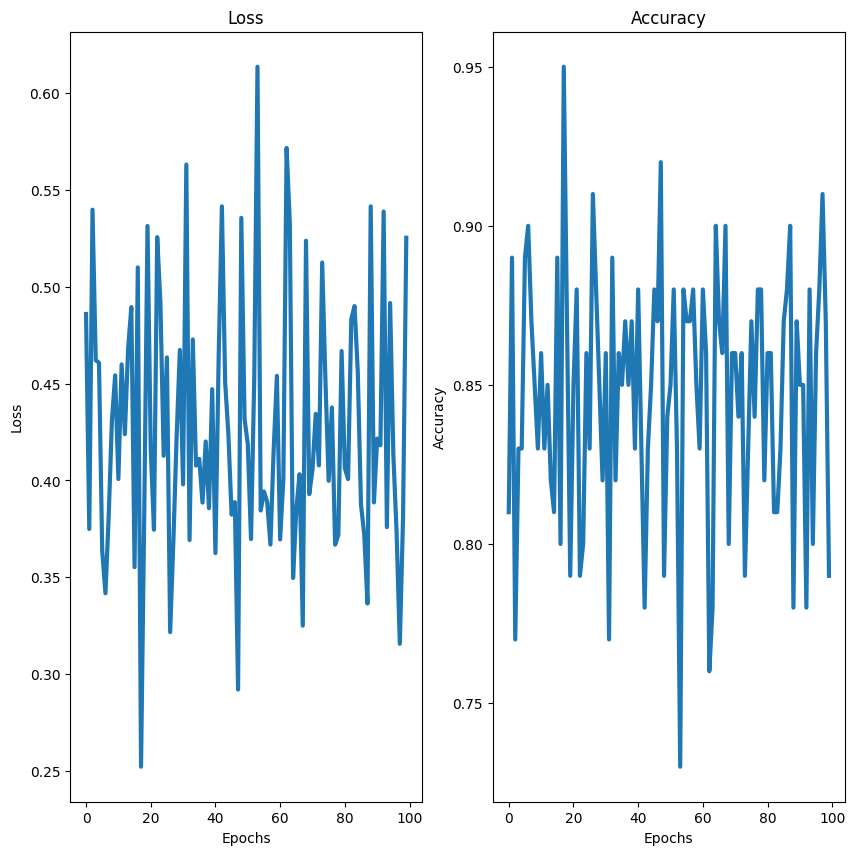

In [34]:
hist=history.history
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(1,2,1)
ax.plot(hist['loss'],lw=3,label='train')
ax.set_title('Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax2=fig.add_subplot(1,2,2) # Corrected: Create a new axis object for the second subplot
ax2.plot(hist['accuracy'],lw=3,label='train') # Corrected: Plot on the new axis ax2
ax2.set_title('Accuracy') # Corrected: Set title for ax2
ax2.set_xlabel('Epochs') # Corrected: Set xlabel for ax2
ax2.set_ylabel('Accuracy') # Corrected: Set ylabel for ax2
plt.show()

In [37]:
ds_test_batched = ds_test.batch(batch_size)
results = CDH_model.evaluate(ds_test_batched)

1620/1620 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8485 - loss: 0.4206


In [38]:
print("test loss, test acc:", results)

test loss, test acc: [0.4205709993839264, 0.8484567999839783]


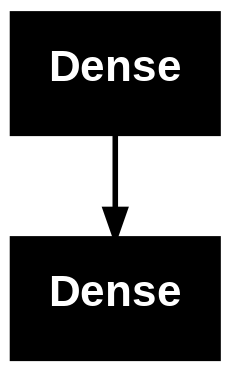

In [39]:
#Plot NN
from tensorflow.keras.utils import plot_model
plot_model(CDH_model)

In [40]:
#save model
CDH_model.save('CDH_model.h5')


In [41]:
#Model Automate
cdh_model=tf.keras.models.load_model('CDH_model.h5')

In [43]:
#predict model
cdh_model.predict(ds_test_batched)

1620/1620 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


array([[0.1413839 ],
       [0.14138351],
       [0.1413839 ],
       ...,
       [0.14138399],
       [0.14821632],
       [0.14143129]], dtype=float32)